## Results

In [18]:
from pathlib import Path


BASE_FOLDER = Path('C:/Users/Pavel/Desktop/PROJECTS/master-thesis/experiments/outputs/streaming/next_activity/baseline/')

BASE_FILENAME = 'results.csv'

PREDICTIONS_DICT = {
    'BPIC_13_C': {
        'darwin': 'bpic_13_c_darwin_classifier_211d8663_2026-04-15_22-52-27',
        # 'darwin_transformer': '',
        'aht': 'bpic_13_c_aht_c1652eae_2026-04-15_22-44-19',
        'arf': 'bpic_13_c_arf_ac2b77f3_2026-04-15_22-45-26',
        'srp': 'bpic_13_c_srp_f890cc58_2026-04-15_23-04-22',
    },
    'BPIC_13_I': {
        'darwin': 'bpic_13_i_darwin_classifier_f5457a3f_2026-04-15_22-52-51',
        # 'darwin_transformer': '',
        'aht': 'bpic_13_i_aht_9b6579da_2026-04-15_22-44-19',
        'arf': 'bpic_13_i_arf_e709e107_2026-04-15_22-45-34',
        'srp': 'bpic_13_i_srp_31aecc01_2026-04-15_23-07-51',
    },
    'BPIC_20_DD': {
        'darwin': 'bpic_20_dd_darwin_classifier_3c0299d4_2026-04-18_17-21-20',
        # 'darwin_transformer': '',
        'aht': 'bpic_20_dd_aht_c24b3254_2026-04-15_22-44-19',
        'arf': 'bpic_20_dd_arf_c23a081c_2026-04-15_22-45-48',
        'srp': 'bpic_20_dd_srp_bf20df3d_2026-04-15_23-09-29',
    },
    'BPIC_20_ID': {
        'darwin': 'bpic_20_id_darwin_classifier_4b5024e5_2026-04-15_22-57-19',
        # 'darwin_transformer': '',
        'aht': 'bpic_20_id_aht_6fe17736_2026-04-15_22-44-19',
        'arf': 'bpic_20_id_arf_f314de13_2026-04-15_22-47-48',
        'srp': 'bpic_20_id_srp_8d4dfdea_2026-04-15_23-14-49',
    },
    'BPIC_20_PTC': {
        'darwin': 'bpic_20_ptc_darwin_classifier_729cf2bb_2026-04-16_10-09-48',
        # 'darwin_transformer': '',
        'aht': 'bpic_20_ptc_aht_4662ecef_2026-04-15_22-44-27',
        'arf': 'bpic_20_ptc_arf_e4bebb94_2026-04-15_22-48-10',
        'srp': 'bpic_20_ptc_srp_772e4d4b_2026-04-15_23-17-16',
    },
    'BPIC_20_RFP': {
        'darwin': 'bpic_20_rfp_darwin_classifier_4b46d157_2026-04-27_22-06-28',
        # 'darwin_transformer': '',
        'aht': 'bpic_20_rfp_aht_a4ff834c_2026-04-15_22-45-08',
        'arf': 'bpic_20_rfp_arf_976c404e_2026-04-15_22-49-37',
        'srp': 'bpic_20_rfp_srp_6d6af37b_2026-04-15_23-37-07',
    },
    'BPIC_20_TPD': {
        'darwin': 'bpic_20_tpd_darwin_classifier_57466802_2026-04-15_23-00-40',
        # 'darwin_transformer': '',
        'aht': 'bpic_20_tpd_aht_0a206627_2026-04-15_22-45-12',
        'arf': 'bpic_20_tpd_arf_5d26b40a_2026-04-15_22-51-11',
        'srp': 'bpic_20_tpd_srp_a96ff756_2026-04-16_07-56-14',
    },
    'Helpdesk': {
        'darwin': 'helpdesk_darwin_classifier_4f4d8b54_2026-04-16_10-37-11',
        # 'darwin_transformer': '',
        'aht': 'helpdesk_aht_dcef8f1c_2026-04-15_22-45-13',
        'arf': 'helpdesk_arf_860e352f_2026-04-15_22-51-57',
        'srp': 'helpdesk_srp_35e698c6_2026-04-16_00-06-03',
    },
}

## Performance plots (archive)

### F-score vs Prefix Length

How good is the model at predicting target when only a few events have been observed?

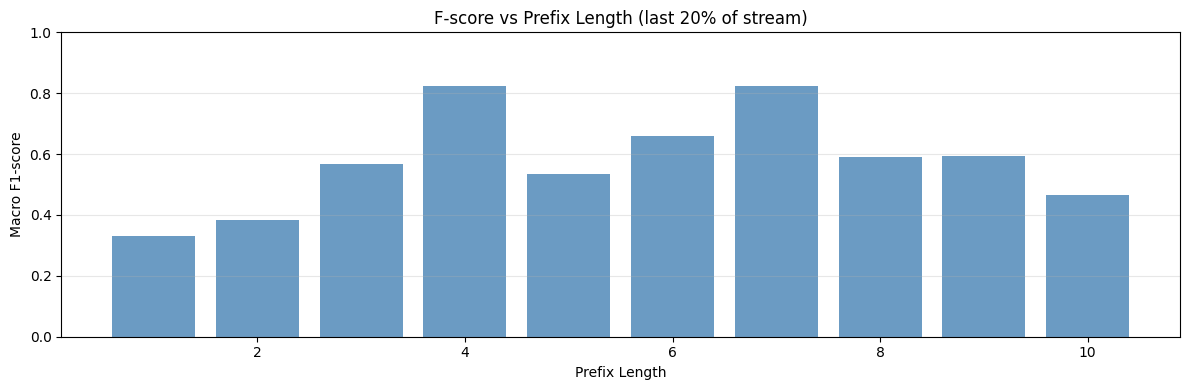

### F-score vs Stream Progress

Is the model performance changing over time? Display drift points

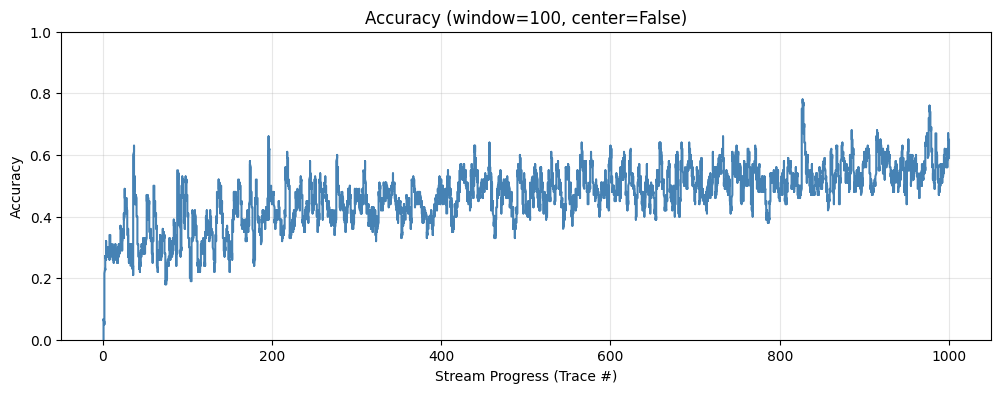

### Prediction Density

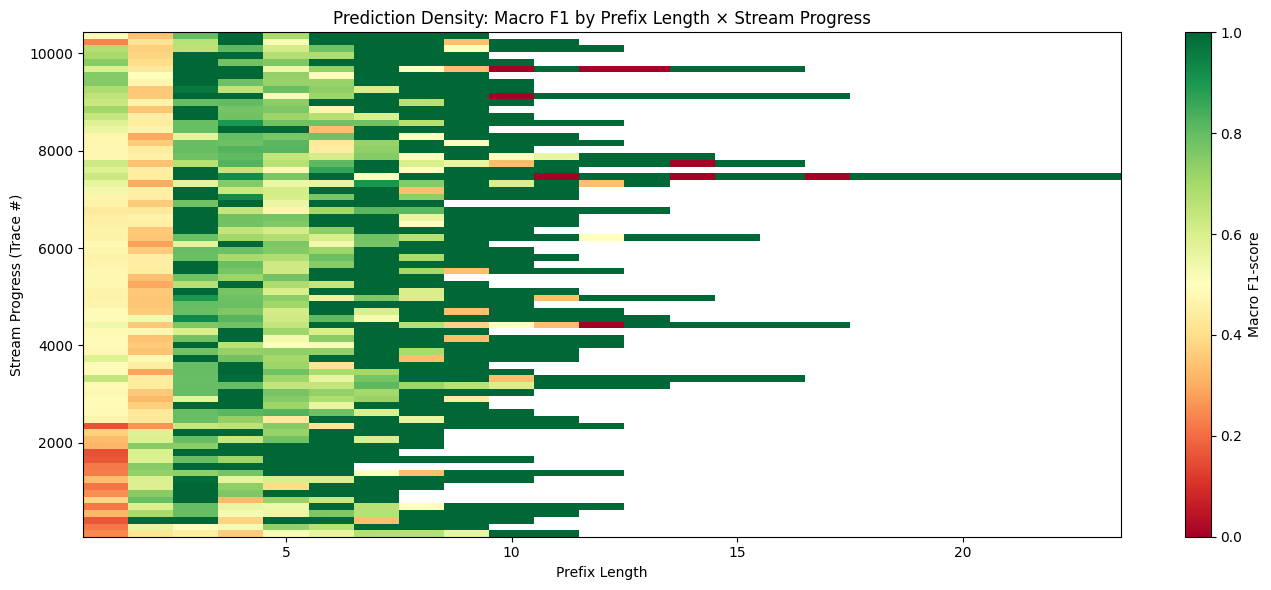

## Comparison table

In [20]:
import pandas as pd
from river import metrics as river_metrics

In [21]:
METRIC_FACTORIES = {
    'macro_f1': river_metrics.MacroF1,
    'accuracy': river_metrics.Accuracy,
}


def recompute_running_metrics(
    predictions_df: pd.DataFrame, start_event_num: int = 0
) -> pd.DataFrame:
    """Recompute running metrics from a given event onwards."""
    metrics_dict = {name: factory() for name, factory in METRIC_FACTORIES.items()}

    predictions_df = (
        predictions_df[predictions_df['event_n'] >= start_event_num]
        .sort_values('event_n')
        .reset_index(drop=True)
        .copy()
    )

    running_values = {name: [] for name in metrics_dict}

    for _, row in predictions_df.iterrows():
        y_true = row['y_true']
        y_pred = row['y_pred']

        if pd.notna(y_true) and pd.notna(y_pred):
            for metric in metrics_dict.values():
                metric.update(y_true, y_pred)

        for metric_name, metric in metrics_dict.items():
            running_values[metric_name].append(f'{metric.get():.3f}')

    for metric_name, values in running_values.items():
        predictions_df[metric_name] = values

    return predictions_df


def first_prediction_event_n(predictions_df: pd.DataFrame) -> float:
    """Return first event_n where model outputs a prediction."""
    pred_mask = pd.notna(predictions_df['y_pred'])

    if 'n_pred' in predictions_df.columns:
        pred_mask &= predictions_df['n_pred'] >= 1

    first_event = predictions_df.loc[pred_mask, 'event_n'].min()
    return first_event

In [22]:
summary_rows = []

for dataset_name, predictions_path_dict in PREDICTIONS_DICT.items():
    # start_event_num = maximum first-prediction event across ALL models in this dataset
    first_pred_events = {}
    for model_name, folder_path in predictions_path_dict.items():
        path = BASE_FOLDER / folder_path / BASE_FILENAME
        df = pd.read_csv(path)
        first_pred_events[model_name] = first_prediction_event_n(df)

    start_event_num = int(max(first_pred_events.values()))

    row = {'dataset_name': dataset_name}

    print(f'Dataset: {dataset_name}, start_event_num: {start_event_num}')

    for model_name, folder_path in predictions_path_dict.items():
        path = BASE_FOLDER / folder_path / BASE_FILENAME
        df = pd.read_csv(path)
        recomputed_df = recompute_running_metrics(df, start_event_num=start_event_num)

        last_row = recomputed_df.iloc[-1]

        for metric in METRIC_FACTORIES.keys():
            row[(metric, model_name)] = last_row[metric]

    summary_rows.append(row)

comparison_table_df = pd.DataFrame(summary_rows).set_index('dataset_name').sort_index()


Dataset: BPIC_13_C, start_event_num: 966
Dataset: BPIC_13_I, start_event_num: 7337
Dataset: BPIC_20_DD, start_event_num: 7335
Dataset: BPIC_20_ID, start_event_num: 8390
Dataset: BPIC_20_PTC, start_event_num: 2130
Dataset: BPIC_20_RFP, start_event_num: 4762
Dataset: BPIC_20_TPD, start_event_num: 10064
Dataset: Helpdesk, start_event_num: 2712


In [23]:
model_order = ['darwin', 'darwin_transformer', 'aht', 'arf', 'srp']
metric_order = ['macro_f1', 'accuracy']

if not comparison_table_df.empty:
    ordered_cols = [
        (metric, model_name)
        for metric in metric_order
        for model_name in model_order
        if (metric, model_name) in comparison_table_df.columns
    ]

    comparison_table_df = comparison_table_df[ordered_cols]
    comparison_table_df.columns = pd.MultiIndex.from_tuples(
        comparison_table_df.columns, names=['metric', 'model']
    )

comparison_table_df

metric       macro_f1                      accuracy                     
model          darwin    aht    arf    srp   darwin    aht    arf    srp
dataset_name                                                            
BPIC_13_C       0.488  0.402  0.454  0.455    0.540  0.566  0.622  0.613
BPIC_13_I       0.518  0.270  0.326  0.318    0.675  0.634  0.637  0.640
BPIC_20_DD      0.421  0.443  0.391  0.461    0.877  0.865  0.890  0.886
BPIC_20_ID      0.475  0.396  0.417  0.414    0.798  0.793  0.823  0.814
BPIC_20_PTC     0.420  0.449  0.494  0.459    0.804  0.818  0.847  0.831
BPIC_20_RFP     0.391  0.384  0.370  0.407    0.866  0.870  0.877  0.867
BPIC_20_TPD     0.358  0.349  0.262  0.240    0.754  0.769  0.624  0.606
Helpdesk        0.238  0.231  0.289  0.279    0.797  0.765  0.822  0.821

## Performance plots

In [8]:
import pandas as pd

In [9]:
# static
START_EVENT_NUM = {
    'BPIC_13_C': 966,
    'BPIC_13_I': 7337,
    'BPIC_20_DD': 7335,
    'BPIC_20_ID': 8390,
    'BPIC_20_PTC': 2130,
    'BPIC_20_RFP': 4762,
    'BPIC_20_TPD': 10064,
    'Helpdesk': 10064,
}

In [10]:
dataset_name = 'BPIC_20_DD'
model_name = 'darwin'

predictions_dir_path = PREDICTIONS_DICT[dataset_name][model_name]

predictions_path = BASE_FOLDER / predictions_dir_path / BASE_FILENAME
predictions_df = pd.read_csv(predictions_path)

In [12]:
predictions_df.tail()

,trace_id,trace_n,event_n,y_true,y_pred,n_pred,n_drifts,drift_detected,prefix_len,loss,accuracy,macro_f1
56432,declaration 100723,2288,56433,Declaration REJECTED by ADMINISTRATION,Declaration APPROVED by ADMINISTRATION,40204,188,False,2,0.16251,0.877276,0.420852
56433,declaration 134592,9724,56434,Declaration APPROVED by ADMINISTRATION,Declaration APPROVED by ADMINISTRATION,40205,188,False,2,0.16251,0.877279,0.420853
56434,declaration 134592,9724,56435,Declaration FINAL_APPROVED by SUPERVISOR,Declaration FINAL_APPROVED by SUPERVISOR,40206,188,False,3,0.16251,0.877282,0.420854
56435,declaration 134592,9724,56436,Request Payment,Request Payment,40207,188,False,4,0.16251,0.877285,0.420854
56436,declaration 134592,9724,56437,Payment Handled,Payment Handled,40208,188,False,5,0.16251,0.877288,0.420854
